# Results & Qualitative Analysis

Reads the structured outputs under `results/` (no retraining) and assembles the
quantitative comparison across all experiments, a deep dive on the **best model selected
from the results**, and the **qualitative analysis** of its predictions. The written cells
here are the source for the results, qualitative and appendix sections of the report.

Run `scripts/run_all.py` and `scripts/make_qualitative.py` first so the outputs exist.

In [1]:
import os, sys

def _find_src():
    d = os.path.abspath(".")
    for _ in range(6):
        if os.path.isdir(os.path.join(d, "src", "detection")):
            return os.path.join(d, "src")
        d = os.path.dirname(d)
    raise RuntimeError("Could not locate src/detection")

SRC = _find_src(); sys.path.insert(0, SRC)
REPO_ROOT = os.path.dirname(SRC)

import pandas as pd
from IPython.display import Image, display

from detection.results_io import load_all_metrics, load_predictions, load_qualitative, best_experiment
from detection.config import EXPERIMENT_NAMES, EXPERIMENTS, CLASS_NAMES

metrics = load_all_metrics()
present = [n for n in EXPERIMENT_NAMES if n in metrics]
best = best_experiment(metrics)
print("Experiments with results:", present)
print("Best experiment (highest test macro-F1):", best)

Experiments with results: ['baseline', 'weighted_k5', 'weighted_k3', 'weighted_k1', 'weighted_dynamic', 'focal_dynamic', 'focal_oversample']
Best experiment (highest test macro-F1): weighted_k1


## Cross-experiment comparison

Macro-F1 on the test set across all experiments. The `full_train` column is the 5-epoch
full-evidence model; the three ablation columns are the 3-epoch input-variant runs.

In [2]:
def comparison_table(metrics):
    rows = []
    for name in EXPERIMENT_NAMES:
        if name not in metrics:
            continue
        m = metrics[name]
        abl = m["ablation"]
        rows.append({
            "experiment": name,
            "maps_to": m.get("maps_to", ""),
            "claim_only": round(abl["claim_only"]["test_macro_f1"], 4),
            "claim+explanation": round(abl["claim+explanation"]["test_macro_f1"], 4),
            "full_evidence (abl)": round(abl["full_evidence"]["test_macro_f1"], 4),
            "full_train F1": round(m["full_train"]["test"]["macro_f1"], 4),
            "best_val_f1": round(m["full_train"]["best_val_f1"], 4),
        })
    return pd.DataFrame(rows).set_index("experiment")

comp = comparison_table(metrics)
comp

,maps_to,claim_only,claim+explanation,full_evidence (abl),full_train F1,best_val_f1
experiment,,,,,,
baseline,,0.3389,0.4179,0.4338,0.4341,0.4454
weighted_k5,,0.4169,0.4116,0.4529,0.4772,0.4985
weighted_k3,,0.3596,0.4261,0.4648,0.4870,0.5010
weighted_k1,,0.4280,0.4183,0.4853,0.5103,0.4963
weighted_dynamic,,0.4214,0.4171,0.4788,0.4913,0.5129
focal_dynamic,,0.4559,0.4306,0.4862,0.4928,0.5097
focal_oversample,,0.4431,0.4558,0.4598,0.4912,0.4991


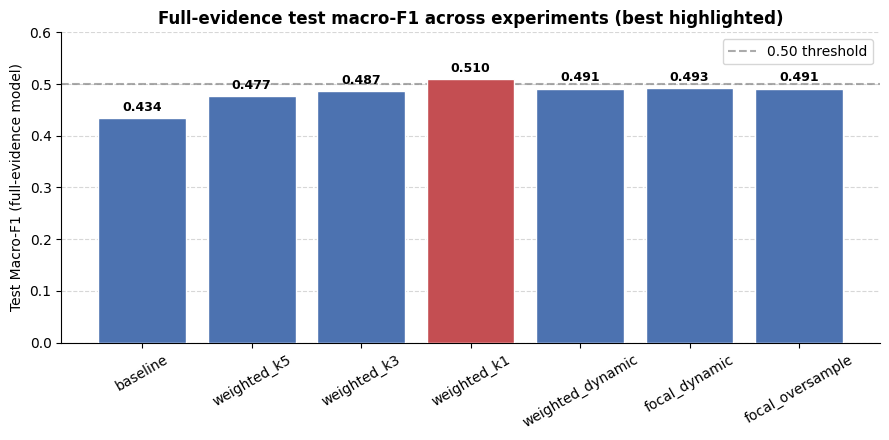

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
order = comp.index.tolist()
bar_colors = ["#C44E52" if n == best else "#4C72B0" for n in order]
ax.bar(order, comp["full_train F1"], color=bar_colors, edgecolor="white", zorder=3)
for i, v in enumerate(comp["full_train F1"]):
    ax.text(i, v + 0.008, f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(0.5, color="#888", linestyle="--", alpha=0.7, label="0.50 threshold")
ax.set_ylabel("Test Macro-F1 (full-evidence model)"); ax.set_ylim(0, max(0.6, comp["full_train F1"].max()+0.05))
ax.set_title("Full-evidence test macro-F1 across experiments (best highlighted)", fontweight="bold")
ax.legend(); ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Best model deep dive

The best model is whichever configuration scored the highest test macro-F1 above
(`best`). Its training curves, ablation, confusion matrix and per-class F1 follow.

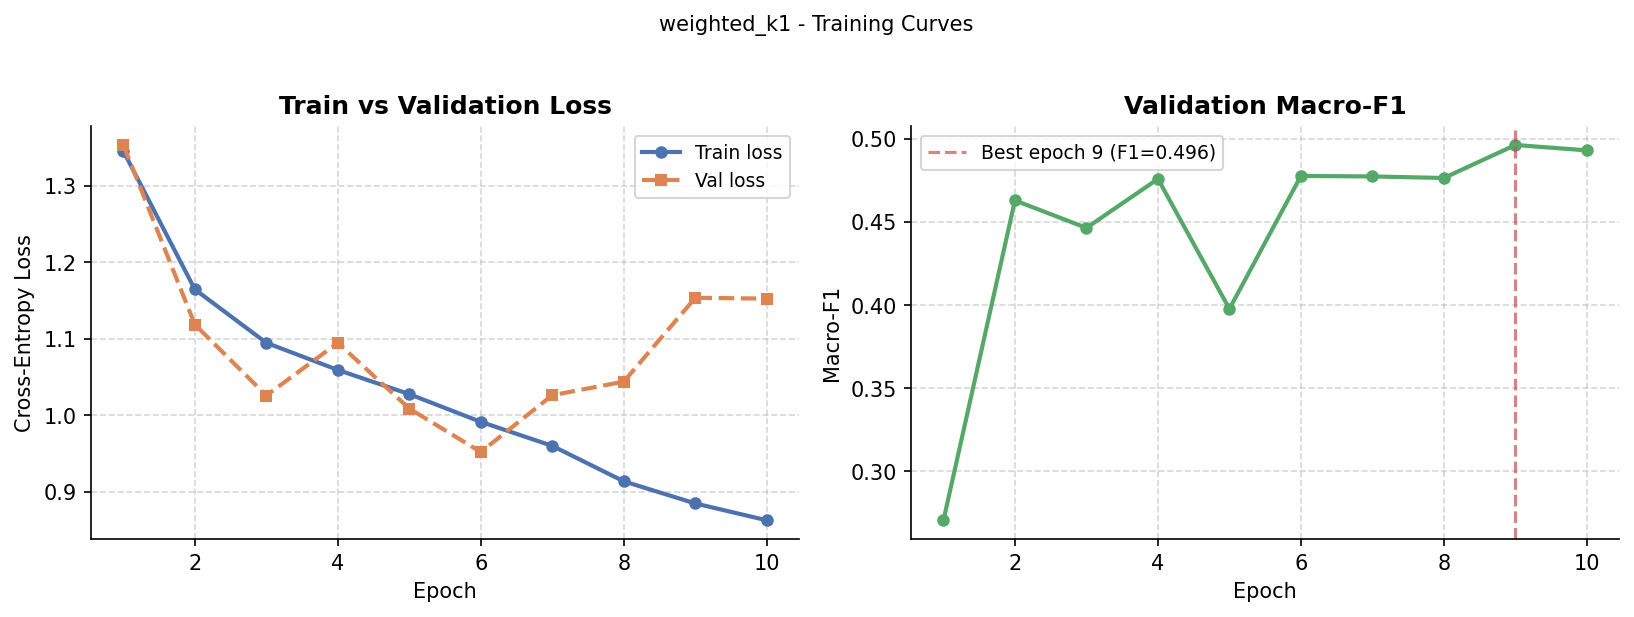

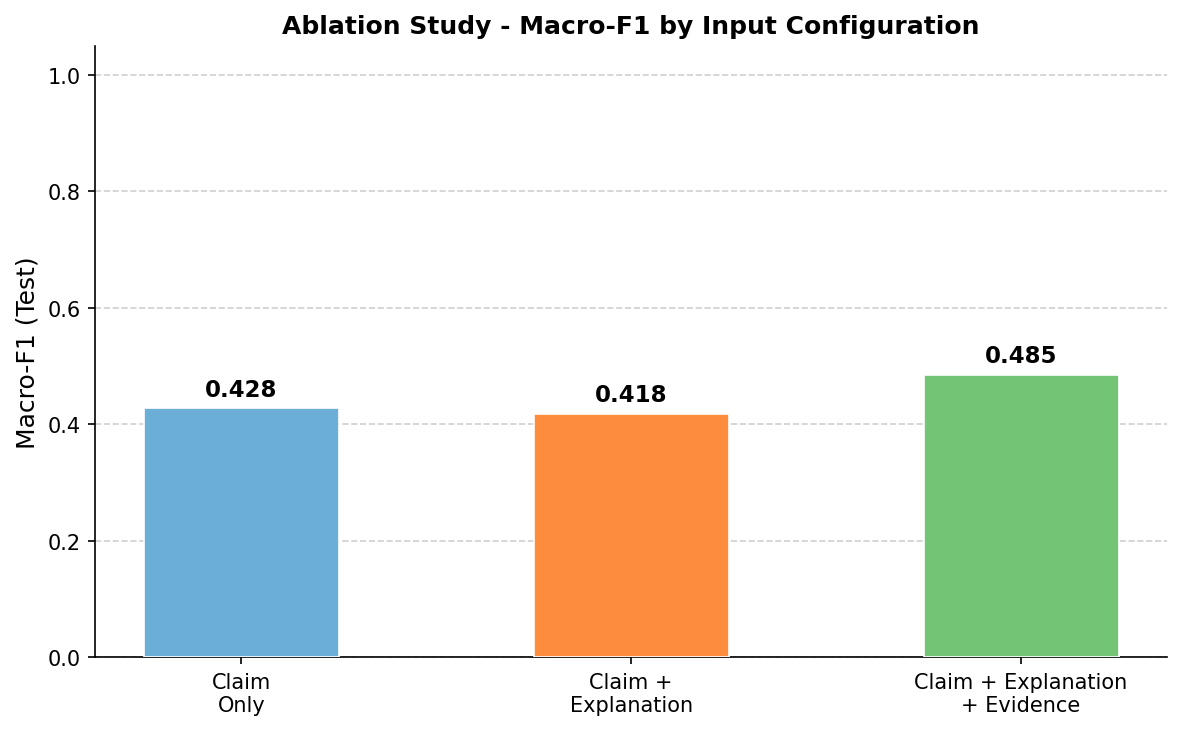

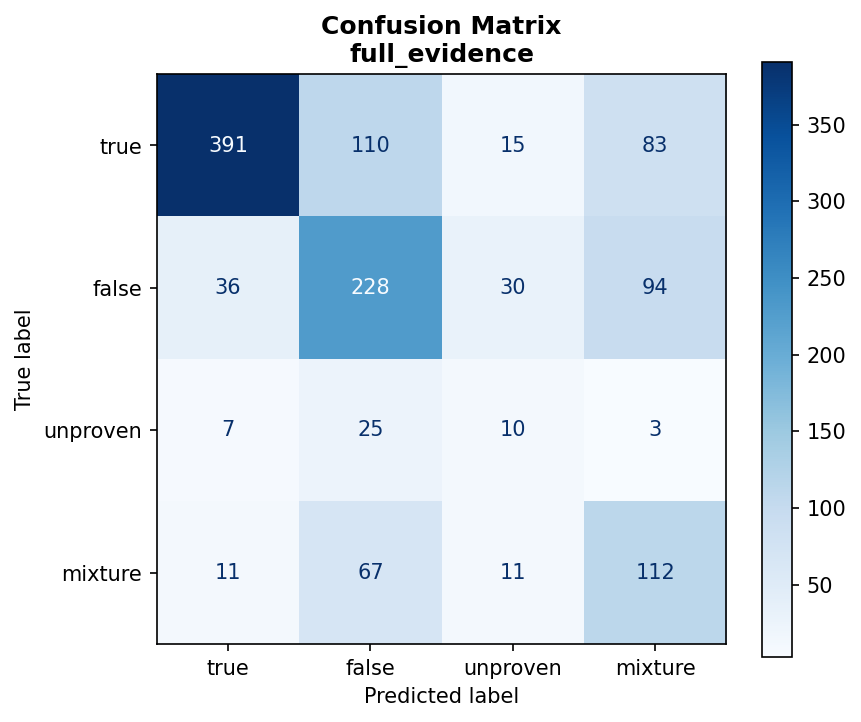

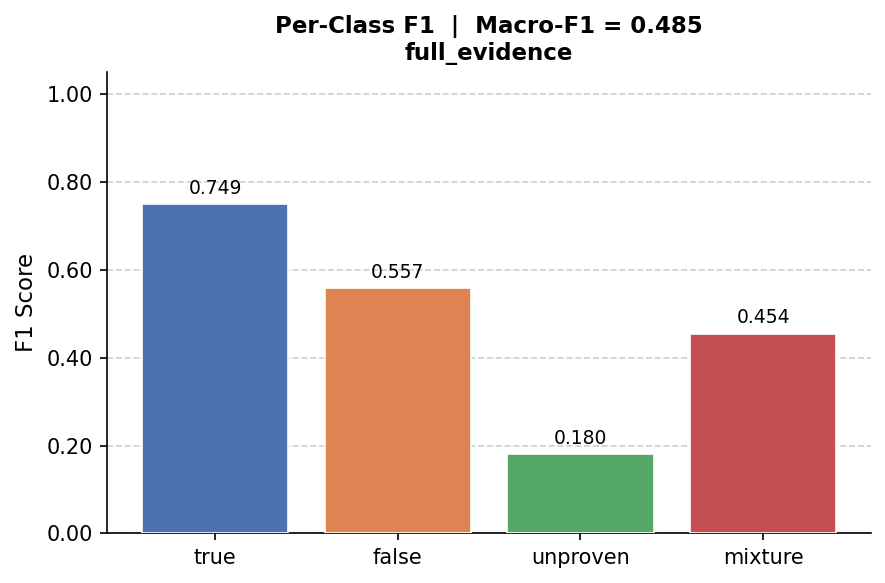

In [4]:
def show_fig(name, fname, width=560):
    path = os.path.join(REPO_ROOT, "results", name, "figures", fname)
    if os.path.exists(path):
        display(Image(filename=path, width=width))
    else:
        print("missing:", path)

show_fig(best, "training_curves.png", width=720)
show_fig(best, "macro_f1_comparison.png", width=560)
show_fig(best, "confusion_full_evidence.png", width=480)
show_fig(best, "f1_perclass_full_evidence.png", width=520)

In [5]:
def per_class_table(m):
    pc = m["full_train"]["test"]["per_class"]
    return pd.DataFrame(pc).T[["precision", "recall", "f1", "support"]].round(3).loc[CLASS_NAMES]

print(f"{best}: test macro-F1 = {metrics[best]['full_train']['test']['macro_f1']:.4f}  "
      f"accuracy = {metrics[best]['full_train']['test']['accuracy']:.4f}")
per_class_table(metrics[best])

weighted_k1: test macro-F1 = 0.5103  accuracy = 0.6050


,precision,recall,f1,support
true,0.903,0.656,0.760,599.0
false,0.583,0.544,0.563,388.0
unproven,0.164,0.467,0.243,45.0
mixture,0.393,0.602,0.475,201.0


## Baseline vs Best (What the imbalance handling buys)

Contrast the unweighted baseline (where the minority classes collapse) against the best
model. The `unproven` row is the clearest signal of progress.

In [6]:
def side_by_side():
    frames = {}
    for name in ["baseline", best]:
        if name in metrics:
            f1 = {c: round(metrics[name]["full_train"]["test"]["per_class"][c]["f1"], 3) for c in CLASS_NAMES}
            frames[name] = f1
    return pd.DataFrame(frames).loc[CLASS_NAMES]

side_by_side()

,baseline,weighted_k1
true,0.763,0.760
false,0.611,0.563
unproven,0.000,0.243
mixture,0.362,0.475


## Qualitative analysis (best model)

Curated predictions from `qualitative.json`: automatic observations, the most confident
mistakes, and errors on the minority classes. This is where we read *why* the model is
right or wrong, not just how often.

In [7]:
qual = load_qualitative(best)
notes = qual["notes"]
print(f"test examples = {notes['n_test']}  accuracy = {notes['accuracy']}")
print(f"mean confidence  correct = {notes['mean_confidence_correct']}   incorrect = {notes['mean_confidence_incorrect']}")
print("per-class recall:", notes["per_class_recall"])
print("\ntop confusion pairs (true -> pred : count):")
for p in notes["top_confusion_pairs"]:
    print(f"  {p['true']:>9} -> {p['pred']:<9} : {p['count']}")

test examples = 1233  accuracy = 0.605
mean confidence  correct = 0.7816   incorrect = 0.5898
per-class recall: {'true': 0.6561, 'false': 0.5438, 'unproven': 0.4667, 'mixture': 0.602}

top confusion pairs (true -> pred : count):
      false -> mixture   : 98
       true -> false     : 90
       true -> mixture   : 86
      false -> unproven  : 54
    mixture -> false     : 47
       true -> unproven  : 30
      false -> true      : 25
    mixture -> unproven  : 23
   unproven -> false     : 14
    mixture -> true      : 10


In [8]:
def render(rows, n=6):
    cols = ["y_true_label", "y_pred_label", "confidence", "claim"]
    df = pd.DataFrame([{c: r.get(c) for c in cols} for r in rows[:n]])
    if "claim" in df:
        df["claim"] = df["claim"].str.slice(0, 110)
    return df

print("Most confident ERRORS (high confidence but wrong)")
display(render(qual["buckets"]["confident_errors"]))
print("Errors on MINORITY classes (unproven / mixture)")
display(render(qual["buckets"]["minority_errors"]))

Most confident ERRORS (high confidence but wrong)


,y_true_label,y_pred_label,confidence,claim
0,unproven,true,0.9917,The new supplement InteliGEN can boost brain f...
1,false,true,0.9917,"300,000 pounds of rat meat sold as chicken win..."
2,mixture,true,0.9917,"The UK is performing 240,000 Covid-19 tests a ..."
3,false,true,0.9913,Winston Churchill was born in a ladies' room d...
4,mixture,true,0.9904,“Heidi Heitkamp: She rubber stamps the Washing...
5,false,true,0.9901,"Viral posts claim that climate change is a ""ma..."


Errors on MINORITY classes (unproven / mixture)


,y_true_label,y_pred_label,confidence,claim
0,unproven,true,0.9917,The new supplement InteliGEN can boost brain f...
1,mixture,true,0.9917,"The UK is performing 240,000 Covid-19 tests a ..."
2,mixture,true,0.9904,“Heidi Heitkamp: She rubber stamps the Washing...
3,unproven,true,0.9892,"1,000 GP practices have closed since 2010."
4,mixture,true,0.9835,Anticoagulants should be used to fight Covid-19.
5,unproven,true,0.9779,Drinking one diet drink a day triples a person...


In [9]:
# Per-class examples: correct vs incorrect for the two hardest classes
for cls in ["unproven", "mixture"]:
    block = qual["per_class_examples"][cls]
    print(f"\n{cls}: correct examples")
    display(render(block["correct"], n=3))
    print(f"{cls}: incorrect examples")
    display(render(block["incorrect"], n=3))


unproven: correct examples


,y_true_label,y_pred_label,confidence,claim
0,unproven,unproven,0.6720,"Employees at a Five Guys restaurant in Daphne,..."
1,unproven,unproven,0.4061,"Last month, 20,000 migrant children were illeg..."
2,unproven,unproven,0.5102,Talk radio host Rush Limbaugh was disqualified...


unproven: incorrect examples


,y_true_label,y_pred_label,confidence,claim
0,unproven,true,0.9917,The new supplement InteliGEN can boost brain f...
1,unproven,true,0.9892,"1,000 GP practices have closed since 2010."
2,unproven,true,0.9779,Drinking one diet drink a day triples a person...



mixture: correct examples


,y_true_label,y_pred_label,confidence,claim
0,mixture,mixture,0.7189,The Westmoreland News ran a KKK ad on the fron...
1,mixture,mixture,0.5403,Treating at the Earliest Sign of MS May Offer ...
2,mixture,mixture,0.6641,"Early in America's history, white Irish slaves..."


mixture: incorrect examples


,y_true_label,y_pred_label,confidence,claim
0,mixture,true,0.9917,"The UK is performing 240,000 Covid-19 tests a ..."
1,mixture,true,0.9904,“Heidi Heitkamp: She rubber stamps the Washing...
2,mixture,true,0.9835,Anticoagulants should be used to fight Covid-19.


## Discussion

**Class weighting is the precondition.** The baseline collapses `unproven` to F1 = 0.000; inverse-frequency weighting immediately revives minority classes.

**Explanation tokens hurt; full evidence helps.** Ablation: claim-only → 0.428, claim+explanation → 0.418 (marginal drop), full evidence → 0.485. Explanations introduce noise; sentence-level retrieval adds discriminative signal.

**Less evidence is better.** `weighted_k1` (top-1 sentence, 0.5103) outperforms `weighted_k3` (0.4870) and `weighted_dynamic` (0.4913). The single most relevant sentence already carries the critical signal.

**Focal loss does not improve over weighted CE.** `focal_dynamic` (0.4928) and `focal_oversample` (0.4912) both fall below `weighted_k1`. Additional complexity is not justified once retrieval is already focused. Oversampling on top of focal loss yields no further gain.

**Qualitative pattern.** Model is well-calibrated (mean confidence 0.782 correct vs 0.590 incorrect). Dominant errors involve genuine label ambiguity: `false`→`mixture` (98), `true`→`false` (90), `true`→`mixture` (86). `unproven` remains hardest (recall 0.467) as absence of evidence is difficult to retrieve.

## Conclusion

- **Best configuration:** `weighted_k1`, weighted cross-entropy with top-1 retrieved sentence (macro-F1 = 0.5103)
- **Key progression:** class weighting → evidence retrieval → focused top-1 selection, each step necessary
- **Negative results:** explanation tokens degrade performance; focal loss and oversampling do not outperform the simpler weighted baseline once retrieval is focused
- **Residual difficulty:** genuine label ambiguity at the `true`/`false`/`mixture` boundary and the evidence-sparse `unproven` class